# 01. Exploratory Data Analysis (EDA)

## Superstore Sales Data Mining Project

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path
sys.path.append('..')

from src.data.loader import DataLoader
from src.data.cleaner import DataCleaner
from src.visualization.plots import plot_distribution, plot_correlation_matrix, plot_category_distribution

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

Matplotlib is building the font cache; this may take a moment.


## 1. Load Data

In [2]:
# Initialize loader
loader = DataLoader(data_path='../data/raw/')

# Generate sample data (or load from file)
df = loader.generate_sample_data(n_orders=2000)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

INFO:src.data.loader:Generated 6986 sample records


Dataset shape: (6986, 21)

First few rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,OD-000001,2021-05-10,2021-05-14,Second Class,Customer-0382,Customer-0382,Home Office,United States,Chicago,Texas,62395,Central,PROD-6160,Office Supplies,Paper,Paper - Item 63,107.88,9,0.15,48.24
1,2,OD-000001,2021-05-10,2021-05-12,Same Day,Customer-0382,Customer-0382,Consumer,United States,San Antonio,Texas,49332,South,PROD-5928,Office Supplies,Supplies,Supplies - Item 65,947.18,3,0.20,79.31
2,3,OD-000002,2033-10-04,2033-10-07,Standard Class,Customer-0532,Customer-0532,Consumer,United States,Philadelphia,California,32852,South,PROD-1929,Technology,Machines,Machines - Item 48,225.71,6,0.00,-23.69
3,4,OD-000002,2033-10-04,2033-10-05,Standard Class,Customer-0532,Customer-0532,Corporate,United States,Phoenix,Pennsylvania,52359,South,PROD-1442,Technology,Machines,Machines - Item 67,964.38,4,0.05,-40.25
4,5,OD-000002,2033-10-04,2033-10-10,First Class,Customer-0532,Customer-0532,Home Office,United States,Los Angeles,Illinois,36417,West,PROD-7268,Technology,Accessories,Accessories - Item 15,492.97,5,0.05,-20.97


## 2. Data Overview

In [3]:
# Inspect data
loader.inspect_data(verbose=True)


DATA INSPECTION SUMMARY

Shape: (6986, 21)

Columns: Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Customer Name, Segment, Country, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit

Duplicate rows: 0

Missing values:

Data types:
  - Row ID: int64
  - Order ID: object
  - Order Date: datetime64[ns]
  - Ship Date: datetime64[ns]
  - Ship Mode: object
  - Customer ID: object
  - Customer Name: object
  - Segment: object
  - Country: object
  - City: object
  - State: object
  - Postal Code: int64
  - Region: object
  - Product ID: object
  - Category: object
  - Sub-Category: object
  - Product Name: object
  - Sales: float64
  - Quantity: int64
  - Discount: float64
  - Profit: float64



{'shape': (6986, 21),
 'columns': ['Row ID',
  'Order ID',
  'Order Date',
  'Ship Date',
  'Ship Mode',
  'Customer ID',
  'Customer Name',
  'Segment',
  'Country',
  'City',
  'State',
  'Postal Code',
  'Region',
  'Product ID',
  'Category',
  'Sub-Category',
  'Product Name',
  'Sales',
  'Quantity',
  'Discount',
  'Profit'],
 'dtypes': {'Row ID': dtype('int64'),
  'Order ID': dtype('O'),
  'Order Date': dtype('<M8[ns]'),
  'Ship Date': dtype('<M8[ns]'),
  'Ship Mode': dtype('O'),
  'Customer ID': dtype('O'),
  'Customer Name': dtype('O'),
  'Segment': dtype('O'),
  'Country': dtype('O'),
  'City': dtype('O'),
  'State': dtype('O'),
  'Postal Code': dtype('int64'),
  'Region': dtype('O'),
  'Product ID': dtype('O'),
  'Category': dtype('O'),
  'Sub-Category': dtype('O'),
  'Product Name': dtype('O'),
  'Sales': dtype('float64'),
  'Quantity': dtype('int64'),
  'Discount': dtype('float64'),
  'Profit': dtype('float64')},
 'head': {'Row ID': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5},
  'Orde

In [4]:
# Column information
loader.get_column_info()

,Column,Data Type,Non-Null Count,Null Count,Unique Values,Sample Values
0,Row ID,int64,6986,0,6986,"[1, 2, 3]"
1,Order ID,object,6986,0,2000,"['OD-000001', 'OD-000001', 'OD-000002']"
2,Order Date,datetime64[ns],6986,0,1701,"[Timestamp('2021-05-10 00:00:00'), Timestamp('..."
3,Ship Date,datetime64[ns],6986,0,3613,"[Timestamp('2021-05-14 00:00:00'), Timestamp('..."
4,Ship Mode,object,6986,0,4,"[np.str_('Second Class'), np.str_('Same Day'),..."
5,Customer ID,object,6986,0,849,"['Customer-0382', 'Customer-0382', 'Customer-0..."
6,Customer Name,object,6986,0,849,"['Customer-0382', 'Customer-0382', 'Customer-0..."
7,Segment,object,6986,0,3,"[np.str_('Home Office'), np.str_('Consumer'), ..."
8,Country,object,6986,0,1,"['United States', 'United States', 'United Sta..."
9,City,object,6986,0,8,"[np.str_('Chicago'), np.str_('San Antonio'), n..."


## 3. Summary Statistics

In [5]:
# Numeric columns statistics
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,6986.000000,6986,6986,6986.000000,6986.000000,6986.000000,6986.000000,6986.000000
mean,3493.500000,2027-04-26 22:59:11.560263168,2027-04-30 10:56:30.781563136,54553.296736,507.942280,5.006155,0.102119,74.695846
min,1.000000,2019-01-02 00:00:00,2019-01-03 00:00:00,10021.000000,10.120000,1.000000,0.000000,-49.950000
25%,1747.250000,2023-04-21 12:00:00,2023-04-26 06:00:00,32236.250000,263.892500,3.000000,0.050000,12.395000
50%,3493.500000,2027-05-28 00:00:00,2027-05-31 00:00:00,54381.500000,512.945000,5.000000,0.100000,73.300000
75%,5239.750000,2031-06-22 00:00:00,2031-06-24 00:00:00,76775.750000,756.335000,7.000000,0.150000,137.185000
max,6986.000000,2035-06-05 00:00:00,2035-06-08 00:00:00,99997.000000,999.960000,9.000000,0.200000,199.970000
std,2016.828823,NaN,NaN,25896.242157,283.773494,2.590737,0.070385,72.247778


In [6]:
# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:")
for col in categorical_cols:
    print(f"\n{col} - {df[col].nunique()} unique values:")
    print(df[col].value_counts().head())

Categorical columns:

Order ID - 2000 unique values:
Order ID
OD-001975    5
OD-001971    5
OD-001969    5
OD-000029    5
OD-000028    5
Name: count, dtype: int64

Ship Mode - 4 unique values:
Ship Mode
First Class       1783
Second Class      1766
Same Day          1719
Standard Class    1718
Name: count, dtype: int64

Customer ID - 849 unique values:
Customer ID
Customer-0670    28
Customer-0828    26
Customer-0915    25
Customer-0302    24
Customer-0770    23
Name: count, dtype: int64

Customer Name - 849 unique values:
Customer Name
Customer-0670    28
Customer-0828    26
Customer-0915    25
Customer-0302    24
Customer-0770    23
Name: count, dtype: int64

Segment - 3 unique values:
Segment
Corporate      2396
Home Office    2321
Consumer       2269
Name: count, dtype: int64

Country - 1 unique values:
Country
United States    6986
Name: count, dtype: int64

City - 8 unique values:
City
Houston        919
Los Angeles    886
San Diego      881
San Antonio    873
Phoenix        870


## 4. Missing Values & Duplicates

In [7]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0]

if len(missing_df) > 0:
    print("Missing values:")
    print(missing_df)
else:
    print("No missing values found!")

# Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

No missing values found!

Duplicate rows: 0


## 5. Distribution Analysis

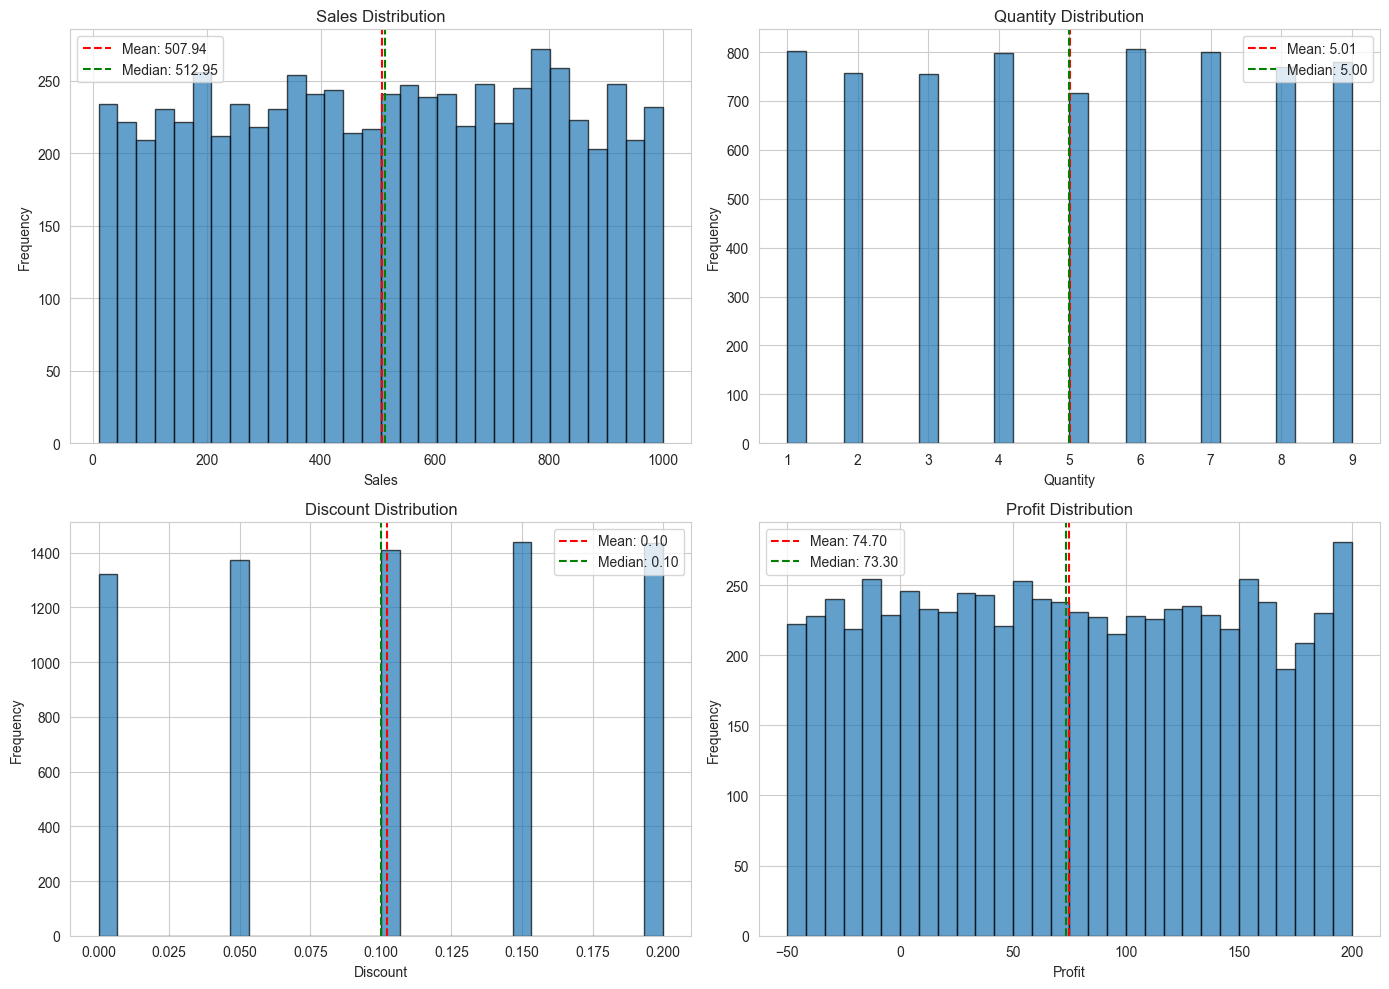

Saved: outputs/figures/01_distribution_numeric.png


In [8]:
# Plot distributions
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{col} Distribution')
    
    # Add statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/01_distribution_numeric.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/figures/01_distribution_numeric.png")

## 6. Category Distribution

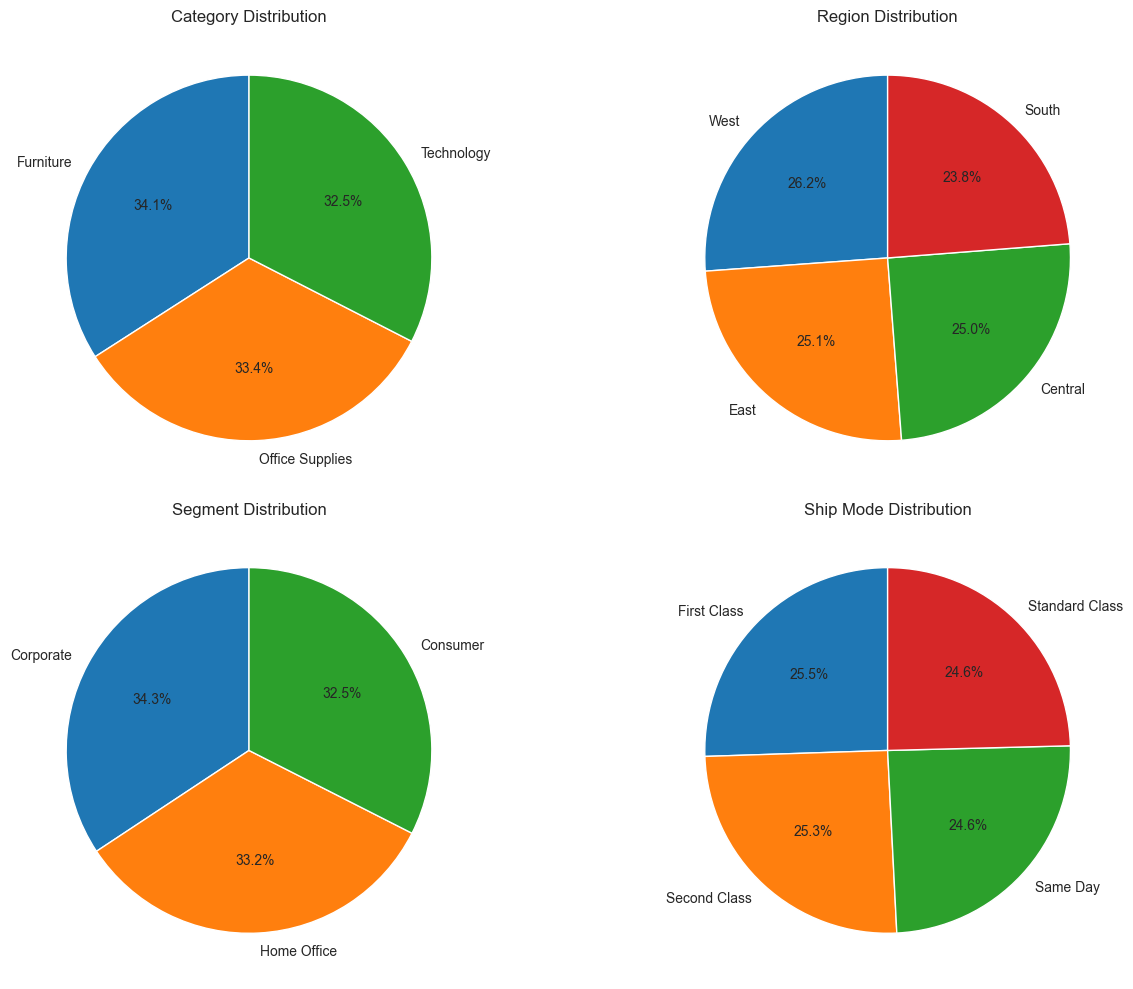

Saved: outputs/figures/02_distribution_category.png


In [9]:
# Plot category distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cat_cols = ['Category', 'Region', 'Segment', 'Ship Mode']

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.savefig('../outputs/figures/02_distribution_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/figures/02_distribution_category.png")

## 7. Correlation Analysis

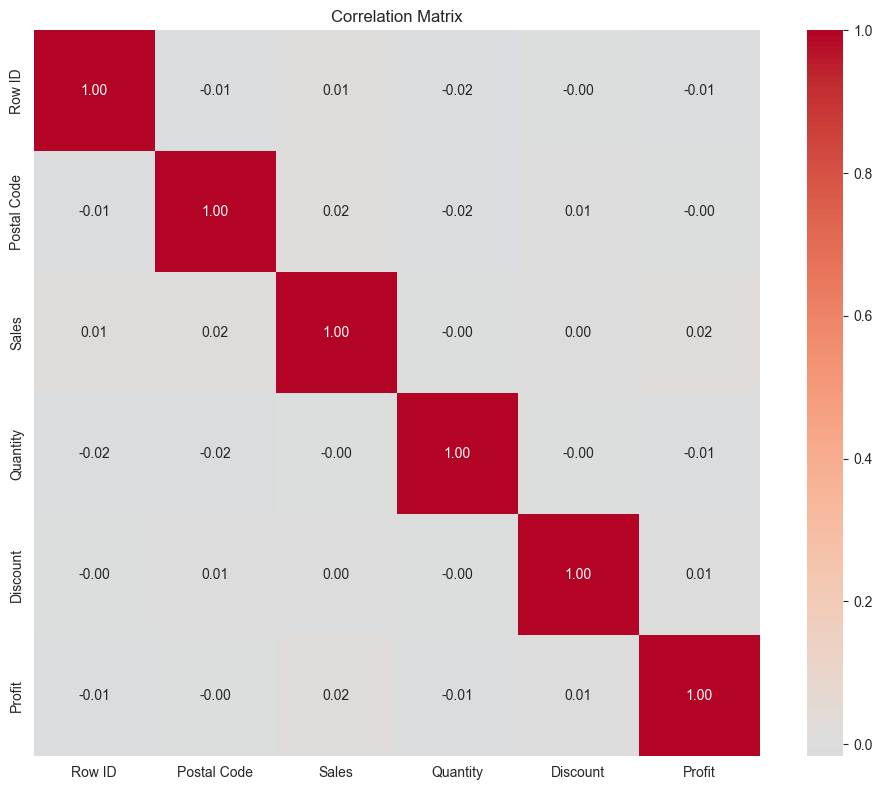

Saved: outputs/figures/03_correlation_matrix.png


In [10]:
# Correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../outputs/figures/03_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/figures/03_correlation_matrix.png")

## 8. Time Series Analysis

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


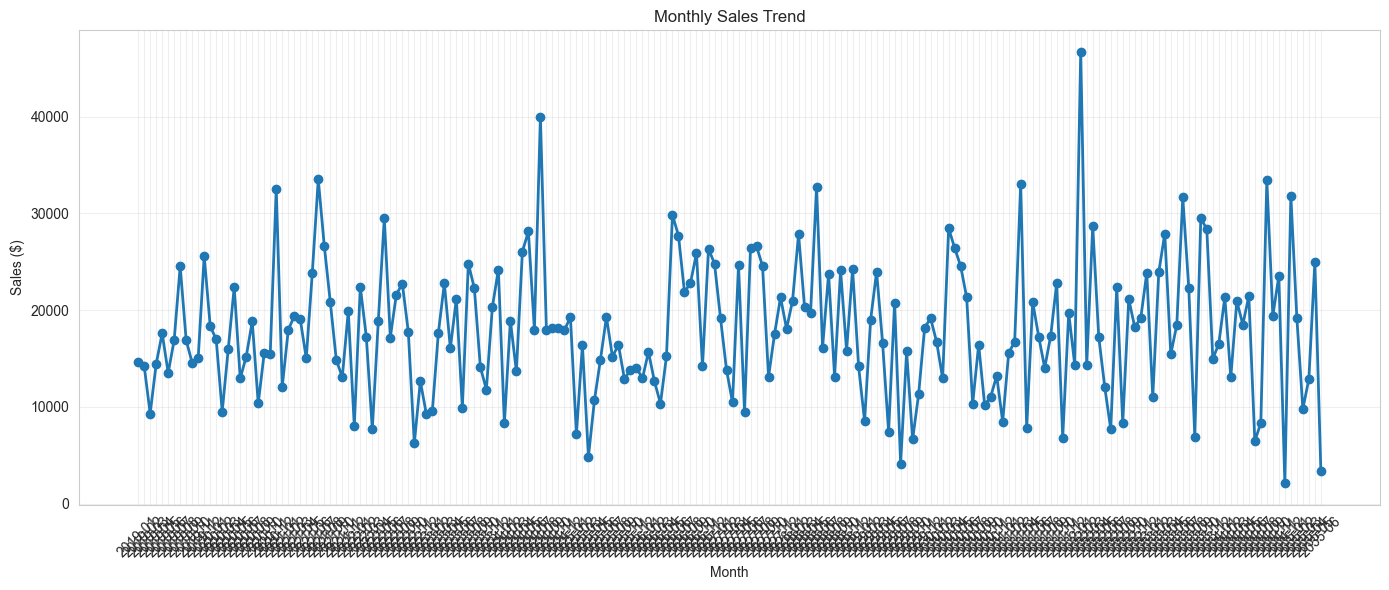

Saved: outputs/figures/04_monthly_sales.png


In [11]:
# Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sales over time (monthly)
df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['Sales'].sum()

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', linewidth=2)
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/04_monthly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/figures/04_monthly_sales.png")

## 9. Sales by Category

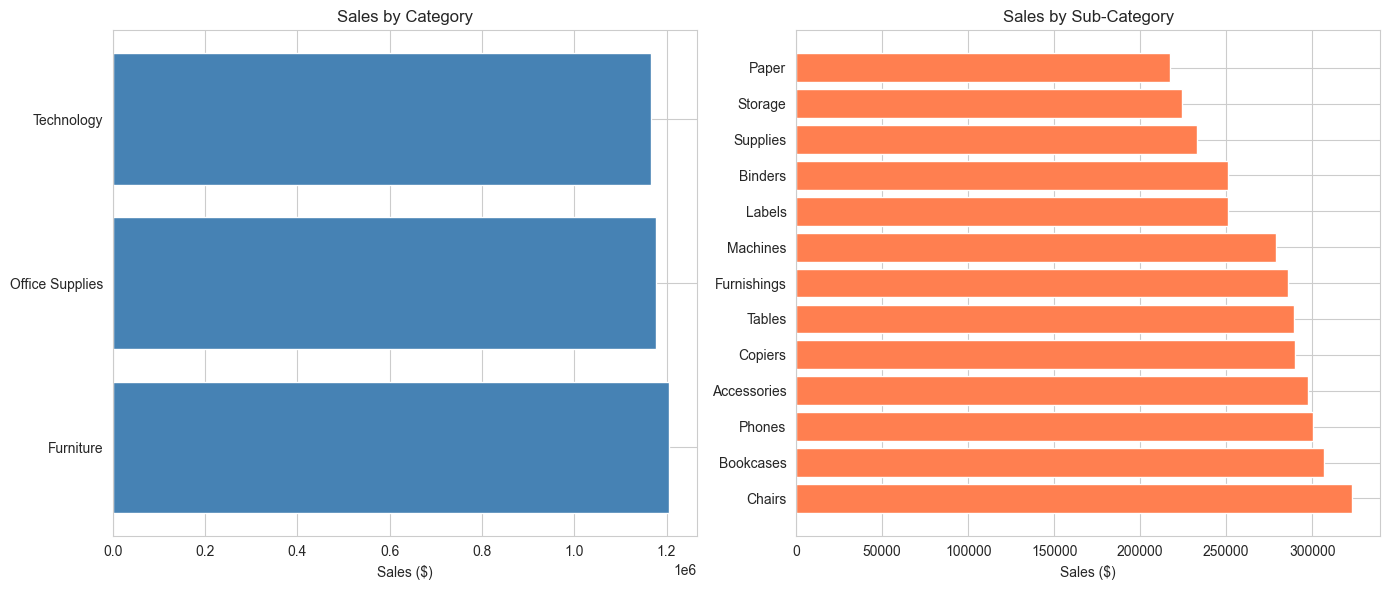

Saved: outputs/figures/05_sales_by_category.png


In [12]:
# Sales by Category and Sub-Category
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# By Category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
axes[0].barh(cat_sales.index, cat_sales.values, color='steelblue')
axes[0].set_xlabel('Sales ($)')
axes[0].set_title('Sales by Category')

# By Sub-Category
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
axes[1].barh(subcat_sales.index, subcat_sales.values, color='coral')
axes[1].set_xlabel('Sales ($)')
axes[1].set_title('Sales by Sub-Category')

plt.tight_layout()
plt.savefig('../outputs/figures/05_sales_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/figures/05_sales_by_category.png")

## 10. Save Summary

In [13]:
# Save cleaned data for next step
df.to_csv('../data/processed/01_eda_data.csv', index=False)

# Summary statistics
summary_stats = loader.get_summary_stats()
print("Summary Statistics:")
for key, value in summary_stats.items():
    print(f"  {key}: {value}")

print("\nEDA completed!")
print("Saved: data/processed/01_eda_data.csv")

Summary Statistics:
  total_orders: 2000
  total_customers: 849
  total_sales: 3548484.77
  total_profit: 521825.18
  date_range: {'min': '2019-01-02 00:00:00', 'max': '2035-06-05 00:00:00'}

EDA completed!
Saved: data/processed/01_eda_data.csv
